# Intro

In this tutorial, we reproduce Fig. 6,7, summarizing the inter-chromosomal causal gene network derived from ARGEN.

# Making sure the package versions for GO analysis are right for the reproduction

In [23]:
# ============================================================
# Speicif versions of Cluster Profiler needed for the reproducing
# ============================================================
install.packages("downloader", repos = "https://cloud.r-project.org")

install.packages(
  "https://bioconductor.org/packages/3.16/data/annotation/src/contrib/org.Hs.eg.db_3.16.0.tar.gz",
  repos = NULL, type = "source"
)
install.packages(
  "https://bioconductor.org/packages/3.16/data/annotation/src/contrib/GO.db_3.16.0.tar.gz",
  repos = NULL, type = "source"
)
install.packages(
  "https://bioconductor.org/packages/3.16/bioc/src/contrib/clusterProfiler_4.6.2.tar.gz",
  repos = NULL, type = "source"
)

Warning message in install.packages("https://bioconductor.org/packages/3.16/bioc/src/contrib/clusterProfiler_4.6.2.tar.gz", :
"installation of package '/var/folders/dh/kjggmk_j6_jbfw1q5d8wwzjm0000gn/T//Rtmp5JN35l/downloaded_packages/clusterProfiler_4.6.2.tar.gz' had non-zero exit status"


The versions should be 4.6.2, 3.16.0 and 3.16.0 for the three packages, respectively.

In [1]:
packageVersion("clusterProfiler")
packageVersion("org.Hs.eg.db")
packageVersion("GO.db")

[1] ‘4.6.2’

[1] ‘3.16.0’

[1] ‘3.16.0’

## Read in packages and set directory

In [1]:
if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman", repos = "https://cloud.r-project.org")

pacman::p_load(
  here, dplyr, data.table, igraph, tidygraph, ggraph, ggplot2,
  Gviz, GenomicRanges, TxDb.Hsapiens.UCSC.hg38.knownGene,
  RColorBrewer, clusterProfiler, org.Hs.eg.db, enrichplot, rtracklayer,ggtext
)



DIR <- here::here() 


source(paste0(DIR,'/code/function/Proxy_IV_functions_parallel.R'))



## Fit ARGEN to large-scale Perturb-seq data.

The ARGEN fitting below could take a long time on a local device with a small number of cores. For reproducing the plots, skip ahead to the next stage.

In [3]:
# -------------------------------
# Paths / output
# -------------------------------
ncores=5
alpha_desc=alpha_IV = 0.01

DAG_DIR <- paste0(DIR,'/results/application/across_chr/')
if (!dir.exists(DAG_DIR)) dir.create(DAG_DIR, recursive = TRUE, showWarnings = FALSE)

# -------------------------------
# Load data (your paths)
# -------------------------------
X_raw  <- readRDS(paste0(DIR,'/data/across_chr/X_raw_400.rds'))
meta_data <- readRDS(paste0(DIR,'/data/across_chr/meta_data_400.rds'))

# Design matrix D (exactly as you had)
perturbation_unique <- unique(meta_data$gene_id)
meta_data$gene_id <- factor(meta_data$gene_id,
                                          levels = unique(meta_data$gene_id))

meta_data$gem_group<-factor(meta_data$gem_group)


D <- model.matrix(~ gene_id - 1, data = meta_data)
colnames(D) <- sub("^gene_id", "", colnames(D))
D <- D[, -c(length(perturbation_unique))]  # keep your exclusion
control_ind <- which(rowSums(D) == 0)

# Offset vector (depth)
C <- meta_data$guide_UMI_sum / mean(meta_data$guide_UMI_sum)




nodes <- colnames(X_raw)
p <- length(nodes)
options(future.globals.maxSize = 10 * 1024^3) 
ds_out <- build_descendants_cov_adjust(
  X_raw = X_raw,
  D = D, 
  control_ind = control_ind,
  alpha_desc = alpha_desc, nodes = nodes,
  padj_method = "BH",
  cc_cols=c('mitopercent'),
  cc_df=meta_data %>% as.data.frame,depth=C,
  ncores = ncores, engine = "multisession", blas_threads = 1
)


setwd(DAG_DIR)
saveRDS(ds_out,'ds_out_covadjust_400.rds')


setwd(DAG_DIR)
ds_out=readRDS('ds_out_covadjust_400.rds')



options(future.globals.maxSize = 10 * 1024^3)

dag_obj <-  dag_search_perturbseq(
  desc_sets = ds_out$descendant_set_score_closure,
  data_raw  = X_raw ,
  D = D, depth = C, family = 'poisson', cc_df = data.frame(meta_data),
  cc_cols = c('mitopercent'), alpha_parent = alpha_IV,
  padj_method_parent = 'onlineBH',
  cores = ncores, blas_threads = 1              
)


# Save DAG artifact (cache)
edges_k <- edges_from_dagsearch(dag_obj)
maps_k  <- compute_ancestors_map(nodes, edges_k)
dag_artifact <- list(
  dag_object    = dag_obj,
  dag_edges     = edges_k,
  parents_map   = maps_k$parents_map,
  ancestors_map = maps_k$ancestors_map
)


saveRDS(dag_artifact, file = file.path(DAG_DIR,'dag_0.01BH_0.01onlineBH_400.rds'))



# Read in meta data

In [2]:
meta_data_allchr <- fread(paste0(DIR,'/data/auxiliary/meta_data_allchr.csv'))
id2name <- meta_data_allchr %>%
  distinct(gene_id, gene) %>%
  mutate(across(everything(), as.character))


DAG_DIR <- paste0(DIR,'/results/application/across_chr/')
setwd(DAG_DIR)
dag_artifact=readRDS(file = 'dag_0.01BH_0.01onlineBH_400.rds')
true_edges=dag_artifact$dag_edges
all_edges=do.call('rbind',dag_artifact$dag_object$edge_structure_all)



true_edges_name=  true_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    dplyr::rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    dplyr::rename(to_gene = gene)


all_edges_name=all_edges %>%
    mutate(from = as.character(from), to = as.character(to)) %>%
    left_join(id2name, by = c("from" = "gene_id")) %>%
    dplyr::rename(from_gene = gene) %>%
    left_join(id2name, by = c("to" = "gene_id")) %>%
    dplyr::rename(to_gene = gene)


edges=true_edges_name
edges=edges %>% mutate(z_score=qnorm(1 -(p_raw+1e-15)/ 2)*sign(coef))
edges=edges %>% mutate(edgescore=(1+tanh(z_score))/2)
edges=edges %>% dplyr::select(from_gene,to_gene,z_score)

# Module clustering and assigning GO terms to each module

In [3]:
# --------------------------------------------------
# 1) Libraries and Setup
# --------------------------------------------------


options(repr.plot.width = 20, repr.plot.height = 20)

stopifnot(all(c("from_gene","to_gene") %in% names(edges)))

# --------------------------------------------------
# 2) Louvain Communities
# --------------------------------------------------
g_u <- graph_from_data_frame(edges[, c("from_gene","to_gene")], 
                             directed = FALSE)

# Optional: use |z| as weight if available
if ("z_score" %in% names(edges)) {
  E(g_u)$weight <- abs(edges$z_score)
}

set.seed(42)
cl_louv <- cluster_louvain(g_u, weights = E(g_u)$weight, resolution = 1.5)
modules_louv <- membership(cl_louv)   # named vector: node -> module id


min_size <- 4
mod_counts <- table(modules_louv)

small_mods <- names(mod_counts)[mod_counts < min_size]
valid_mods <- names(mod_counts)[mod_counts >= min_size]


if (length(small_mods) > 0 && length(valid_mods) > 0) {
  
  weight_attr <- if(!is.null(E(g_u)$weight)) "weight" else NULL
  adj_mat <- as_adjacency_matrix(g_u, attr = weight_attr, sparse = FALSE)
  
  largest_mod <- names(mod_counts)[which.max(mod_counts)]
  
  genes_to_reassign <- names(modules_louv)[modules_louv %in% small_mods]
  
  for (gene in genes_to_reassign) {
    conn_scores <- sapply(valid_mods, function(m) {
      m_genes <- names(modules_louv)[modules_louv == m]
      sum(adj_mat[gene, m_genes])
    })
    

    best_mod <- valid_mods[which.max(conn_scores)]
    
    if (max(conn_scores) == 0) {
      best_mod <- largest_mod
    }
    
    modules_louv[gene] <- best_mod
  }
}


# -------------------------------
# Helper: shorten GO description
# -------------------------------
shorten_term <- function(x, width = 38) {
  x <- gsub("\\s*\\(GO:\\d+\\)$", "", x)  # drop trailing "(GO:...)"
  ifelse(
    nchar(x) <= width,
    x,
    paste0(substr(x, 1, width - 1), "…")
  )
}

# ============================================================
# 1) Enrichment: top k GO terms per Louvain module
# ============================================================

# All genes present in Louvain result
sym_all <- unique(names(modules_louv))

# SYMBOL -> ENTREZ
sym2ent <- bitr(sym_all,
                fromType = "SYMBOL",
                toType   = "ENTREZID",
                OrgDb    = org.Hs.eg.db)

# Universe for GO
all_genes=c(all_edges_name$from_gene,all_edges_name$to_gene) %>% unique# all 400

sym2ent_all <- bitr(all_genes,
                fromType = "SYMBOL",
                toType   = "ENTREZID",
                OrgDb    = org.Hs.eg.db)


bg_entrez <- unique(sym2ent_all$ENTREZID)

# Split genes by Louvain module ID
mods_louv <- split(names(modules_louv), modules_louv)

# ---- choose how many GO terms to show per module in legend ----
k_top <- 3

# ---- compute top k GO terms per module ----
module_go_list <- lapply(names(mods_louv), function(mid) {
  genes_sym <- mods_louv[[mid]]

  eg <- unique(sym2ent$ENTREZID[ match(genes_sym, sym2ent$SYMBOL) ])
  eg <- eg[!is.na(eg)]
  if (length(eg) == 0L) return(NULL)

  ego <- tryCatch(
    enrichGO(
      gene          = eg,
      universe      = bg_entrez,
      OrgDb         = org.Hs.eg.db,
      keyType       = "ENTREZID",
      ont           = "BP",
      pAdjustMethod = "BH",
      pvalueCutoff  = 1,
      qvalueCutoff  = 1,
      readable      = TRUE
    ),
    error = function(e) NULL
  )
  if (is.null(ego)) return(NULL)

  df <- tryCatch(as.data.frame(ego), error = function(e) NULL)
  if (is.null(df) || nrow(df) == 0L) return(NULL)

  # order by smallest adjusted p-value (you can change rule if needed)
  o  <- order(df$p.adjust, df$qvalue, na.last = NA)
  df <- df[o, , drop = FALSE]

  # keep top k_top
  df <- head(df, k_top)

  # parse GeneRatio "a/b"
  gr_str <- as.character(df$GeneRatio)
  gr_num <- suppressWarnings({
    sapply(strsplit(gr_str, "/"), function(z) {
      if (length(z) == 2) as.numeric(z[1]) / as.numeric(z[2]) else NA_real_
    })
  })

  data.frame(
    module        = mid,
    rank          = seq_len(nrow(df)),        # 1,2,...,k_top
    Description   = as.character(df$Description),
    pvalue        = df$pvalue,
    p.adjust      = df$p.adjust,
    qvalue        = df$qvalue,
    GeneRatio     = gr_str,
    GeneRatio_num = gr_num,
    BgRatio       = as.character(df$BgRatio),
    Count         = as.integer(df$Count),
    stringsAsFactors = FALSE
  )
})

# bind into one table: one row per (module, rank)
module_go_topk <- do.call(rbind, module_go_list)

if (is.null(module_go_topk) || nrow(module_go_topk) == 0L) {
  stop("No GO terms found for any module.")
}

module_go_top1 <- module_go_topk[module_go_topk$rank == 1, , drop = FALSE]

module_labels_louv <- setNames(
  module_go_top1$Description,
  module_go_top1$module
)



'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(sym_all, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
"7.02% of input gene IDs are fail to map..."
'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(all_genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
"2.75% of input gene IDs are fail to map..."


# Fig. 6a

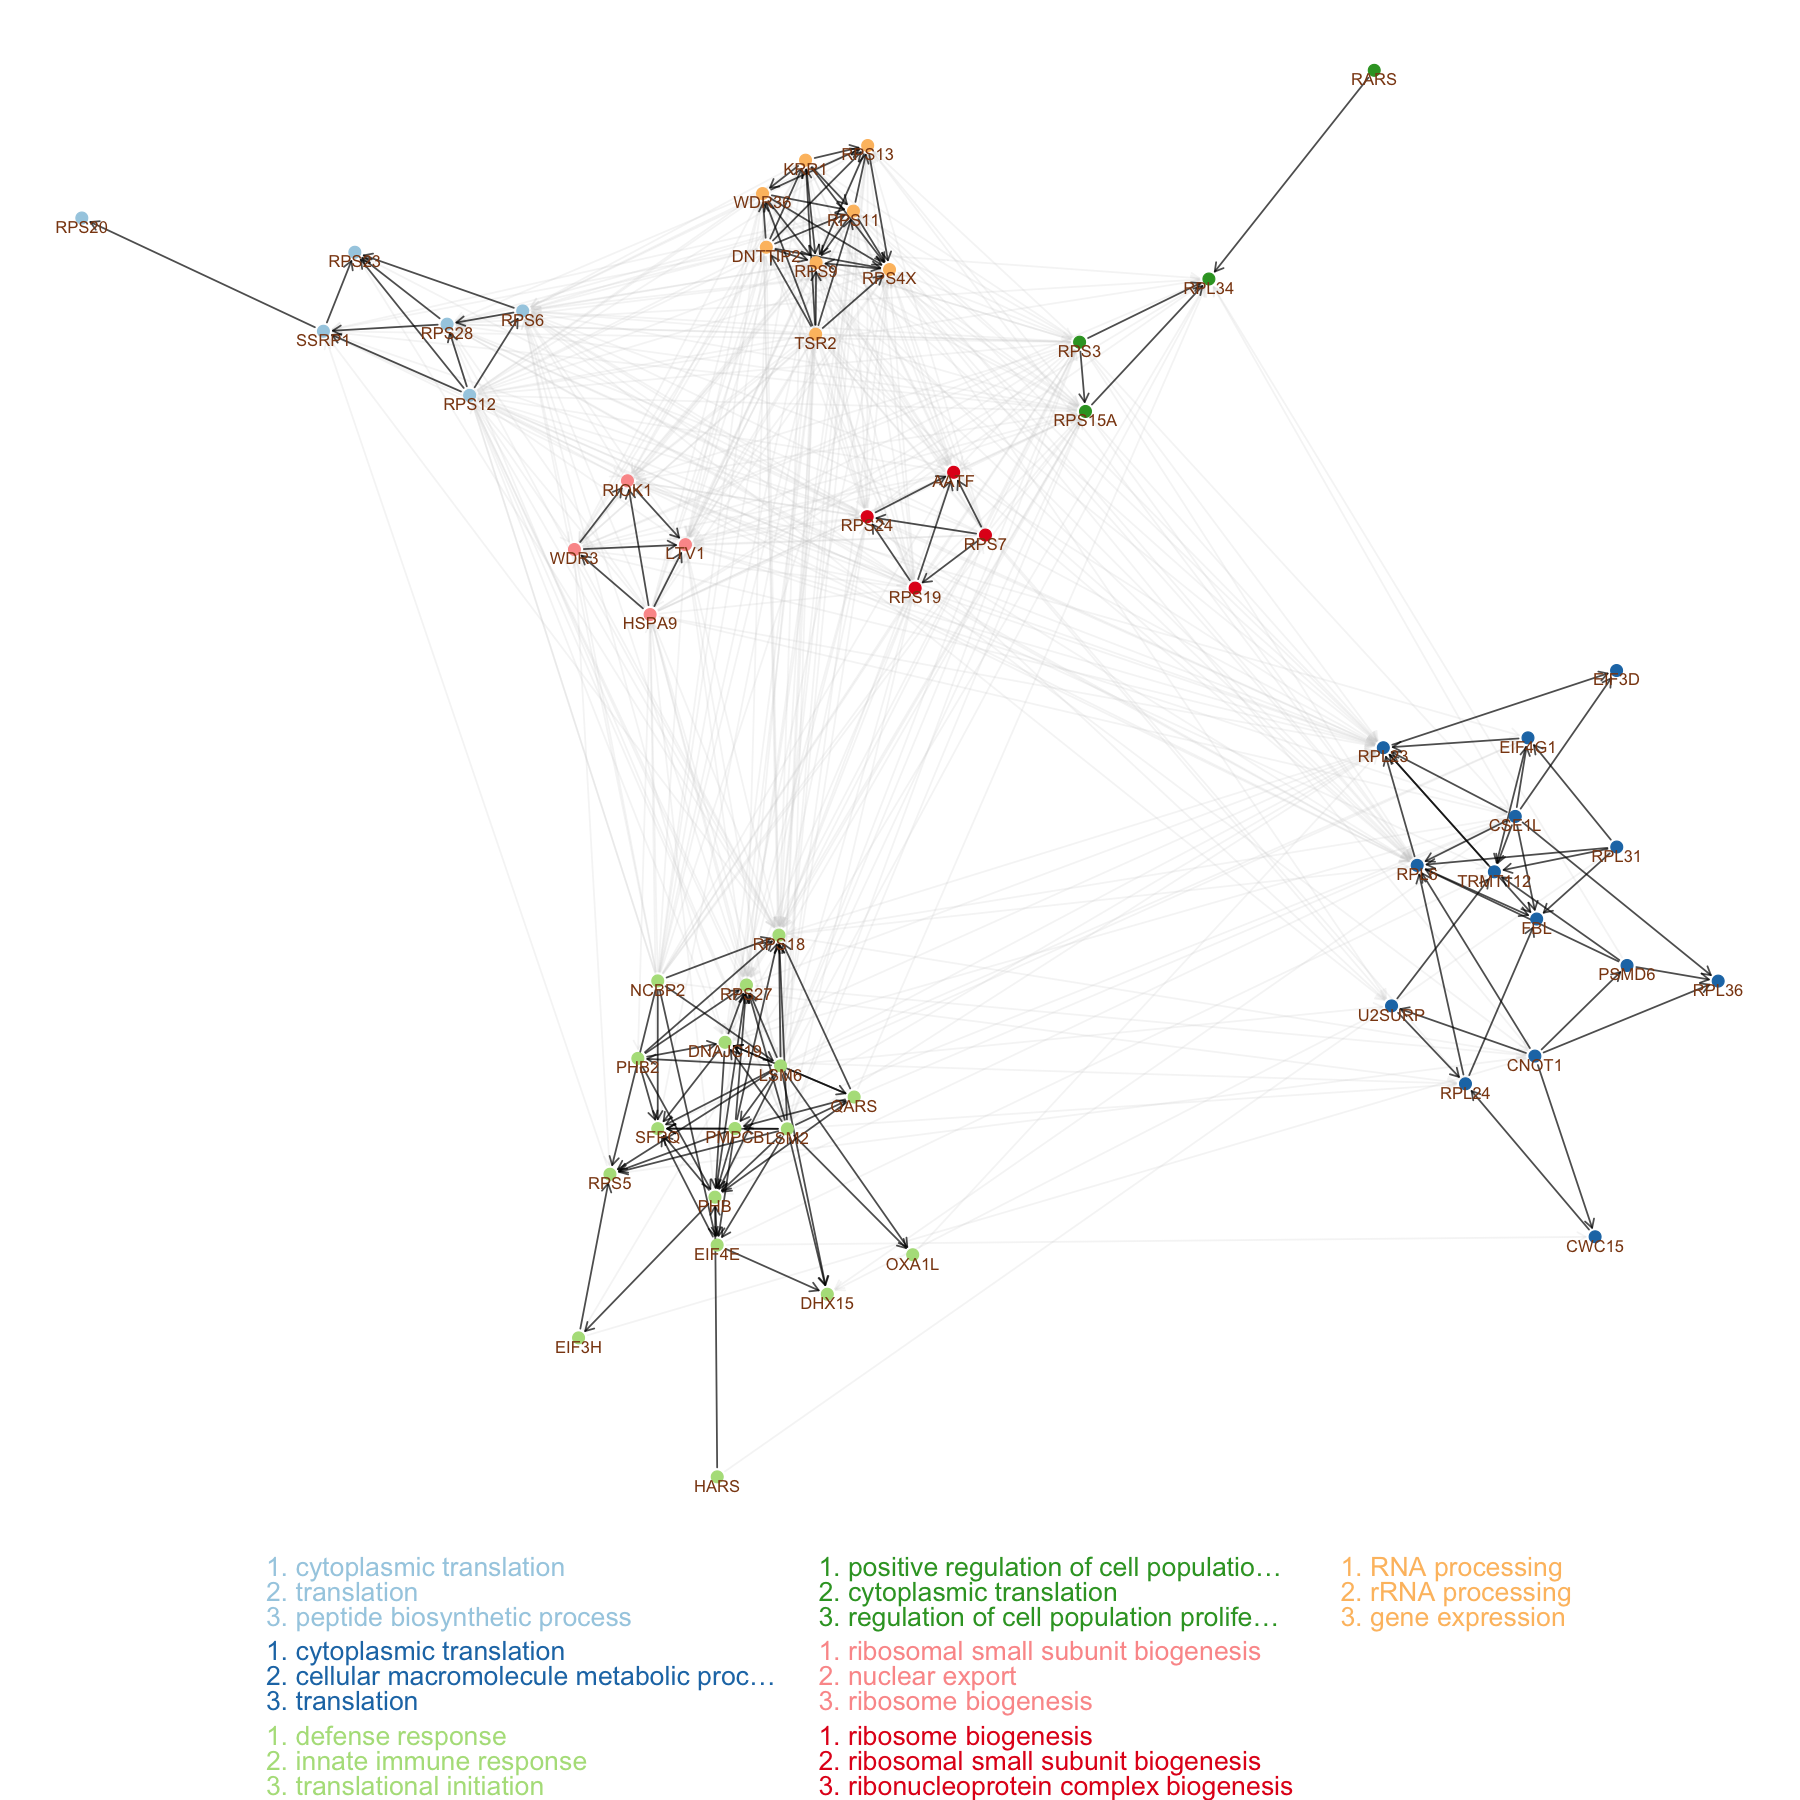

In [4]:

options(repr.plot.width = 15, repr.plot.height = 15)
# ============================================================
# 2) Build directed graph, attach modules
# ============================================================

# edges must have columns: from_gene, to_gene
g <- graph_from_data_frame(edges[, c("from_gene", "to_gene")],
                           directed = TRUE)

# Attach Louvain module id to vertices
V(g)$module_id <- modules_louv[V(g)$name]

# unique module ids
mod_ids <- sort(unique(V(g)$module_id))

# ============================================================
# 3) Distinct color scheme for modules
#    - order modules by top-1 GO term (alphabetical)
# ============================================================

# GO label for each module_id (unwrapped; rank 1)
go_labels_by_mod <- setNames(
  vapply(mod_ids, function(i) {
    lbl <- module_labels_louv[[as.character(i)]]
    if (is.null(lbl)) "no signal" else lbl
  }, character(1)),
  as.character(mod_ids)
)

# order module IDs by GO term alphabetically
mod_ids_ord <- names(sort(tolower(go_labels_by_mod)))
n_mod       <- length(mod_ids_ord)

# base palette
base_cols <- brewer.pal(min(max(n_mod, 3), 12), "Paired")
base_cols <- colorRampPalette(base_cols)(n_mod)

# assign colors in GO-alphabetic order
mod_cols <- setNames(base_cols, mod_ids_ord)

# attach colors to nodes
V(g)$module_color <- mod_cols[as.character(V(g)$module_id)]

# ============================================================
# 4) Mark intra- vs inter-module edges
# ============================================================

e_ends   <- ends(g, E(g), names = TRUE)
same_mod <- V(g)$module_id[match(e_ends[,1], V(g)$name)] ==
            V(g)$module_id[match(e_ends[,2], V(g)$name)]

E(g)$is_intra <- same_mod
E(g)$w_intra  <- ifelse(same_mod, 3, 0.05)

# clean accidental edge attrs (if needed)
for (nm in edge_attr_names(g)) {
  if (!nm %in% c("is_intra", "w_intra")) {
    g <- delete_edge_attr(g, nm)
  }
}

# ============================================================
# 5) Layout (Fruchterman-Reingold with intra-module weights)
# ============================================================

set.seed(1)
lay <- layout_with_fr(g, weights = E(g)$w_intra, niter = 2000)
tg  <- as_tbl_graph(g)

# representative color per module_id (just majority vote; all same anyway)
id2color <- V(g)$module_color %>%
  split(V(g)$module_id) %>%
  lapply(function(v) v[which.max(tabulate(match(v, v)))]) %>%
  unlist()

id_levels <- sort(unique(V(g)$module_id))

# ============================================================
# 6) Legend labels: numbered GO terms for each module
# ============================================================

# build multi-line labels:
vals_labels <- setNames(
  vapply(id_levels, function(i) {
    mid <- as.character(i)
    dfm <- module_go_topk[module_go_topk$module == mid, , drop = FALSE]

    if (is.null(dfm) || nrow(dfm) == 0L) return("no signal")

    dfm  <- dfm[order(dfm$rank), , drop = FALSE]
    desc <- shorten_term(dfm$Description, width = 38)

    paste0(seq_len(nrow(dfm)), ". ", desc, collapse = "\n")
  }, character(1)),
  as.character(id_levels)
)

ordered_ids <- names(sort(tolower(go_labels_by_mod)))

vals_labels <- vals_labels[ordered_ids]
vals_colors <- setNames(
  as.character(id2color[ordered_ids]),
  ordered_ids
)

vals_labels_colored <- setNames(
  mapply(function(lbl, col) {
    lbl_html <- gsub("\n", "<br>", lbl, fixed = TRUE)
    paste0("<span style='color:", col, ";'>", lbl_html, "</span>")
  }, vals_labels, vals_colors, SIMPLIFY = TRUE),
  names(vals_labels)
)

# ============================================================
# 7) Final DAG plot
# ============================================================

g_dag <- ggraph(tg, layout = "manual", x = lay[,1], y = lay[,2]) +
  geom_edge_link(
    aes(filter = !is_intra),
    colour      = "grey80",
    alpha       = 0.2,
    show.legend = FALSE,
    arrow       = arrow(length = unit(2, "mm")),
    start_cap   = circle(2, "mm"),
    end_cap     = circle(2, "mm"),
    lineend     = "round"
  ) +
  geom_edge_link(
    aes(filter =  is_intra),
    colour      = "black",
    alpha       = 0.7,
    show.legend = FALSE,
    arrow       = arrow(length = unit(2, "mm")),
    start_cap   = circle(2, "mm"),
    end_cap     = circle(2, "mm"),
    lineend     = "round"
  ) +
  geom_node_point(aes(color = factor(module_id)), size = 3) +
  geom_node_text(aes(label = name),
                 size = 3.5, vjust = 1.2, check_overlap = TRUE,color="chocolate4") +
  scale_color_manual(
    values = vals_colors,
    breaks = names(vals_labels_colored),
    labels = vals_labels_colored,
    name   = paste0("Louvain module (top ", k_top, " GO:BP terms)")
  ) +
guides(color = guide_legend(
  override.aes = list(
    shape = NA,
    linetype = 0,
    size = 0,
    color = NA
  ),
  ncol = 3
)) +
  theme_void() +
  theme(
    legend.position = "bottom",
    legend.text     = ggtext::element_markdown(size = 16),  # <- colored text
    legend.title    = element_blank(),
    plot.title      = element_blank()
  ) +
  ggtitle("Network colored by Louvain modules (GO:BP enrichment)")

g_dag

# Summary of edges

In [5]:
edges_df <- true_edges_name %>% mutate(z_score=qnorm(1 -(p_raw+1e-15)/ 2)*sign(coef))


g <- graph_from_data_frame(
  edges_df[, c("from_gene","to_gene","z_score")],
  directed = TRUE
)


V(g)$module_id <- modules_louv[V(g)$name]

E(g)$weight <- abs(edges_df$z_score)


out_deg <- degree(g, mode = "out")
in_deg  <- degree(g, mode = "in")
bet     <- betweenness(g, directed = TRUE, weights = 1/E(g)$weight)
close   <- closeness(g, mode = "out", weights = 1/E(g)$weight)
pager   <- page_rank(g, directed = TRUE)$vector
katz <- alpha_centrality(g,nodes = V(g),alpha = 0.025)          # constant bias term
hub     <- hub_score(g, weights = E(g)$weight)$vector
auth    <- authority_score(g, weights = E(g)$weight)$vector

deg_tbl <- tibble(
  gene        = names(out_deg),
  outdegree   = out_deg,
  indegree    = in_deg,
  betweenness = bet,
  closeness   = close,
  pagerank    = pager,
  katz        = katz,
  hub_score   = hub,
  auth_score  = auth
)

deg_tbl <- deg_tbl %>%
  mutate(total_degree = indegree + outdegree) %>%
  arrange(desc(total_degree))


deg_tbl

Warning message:
"`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead."
Warning message:
"`authority_score()` was deprecated in igraph 2.1.0.
ℹ Please use `hits_scores()` instead."


gene,outdegree,indegree,betweenness,closeness,pagerank,katz,hub_score,auth_score,total_degree
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RPS12,28,2,11.5,0.07003042,0.006404366,1.371571,9.947871e-01,0.1449862110,30
RPS3,21,9,53.0,0.06825171,0.009155204,3.957888,7.833134e-01,0.7757328714,30
RPS15A,16,14,13.0,0.06108878,0.011147176,6.069831,3.958840e-01,0.7656445710,30
HSPA9,25,4,41.0,0.07518067,0.006969949,1.913824,1.000000e+00,0.3269697312,29
RPS19,21,8,38.5,0.06711388,0.008465052,3.170808,7.450803e-01,0.6651779377,29
RPS24,19,10,14.0,0.05858257,0.009768303,4.831401,5.595526e-01,0.8025659501,29
RPL23,2,27,64.0,2.13244221,0.104726189,12.830215,7.548488e-04,0.5585122881,29
LSM6,25,3,19.0,0.06877027,0.006380471,1.453696,5.655956e-01,0.1928277159,28
RPS18,5,23,58.0,0.14333795,0.022607014,9.043388,5.521693e-02,0.6309015145,28


# Fig. 6b

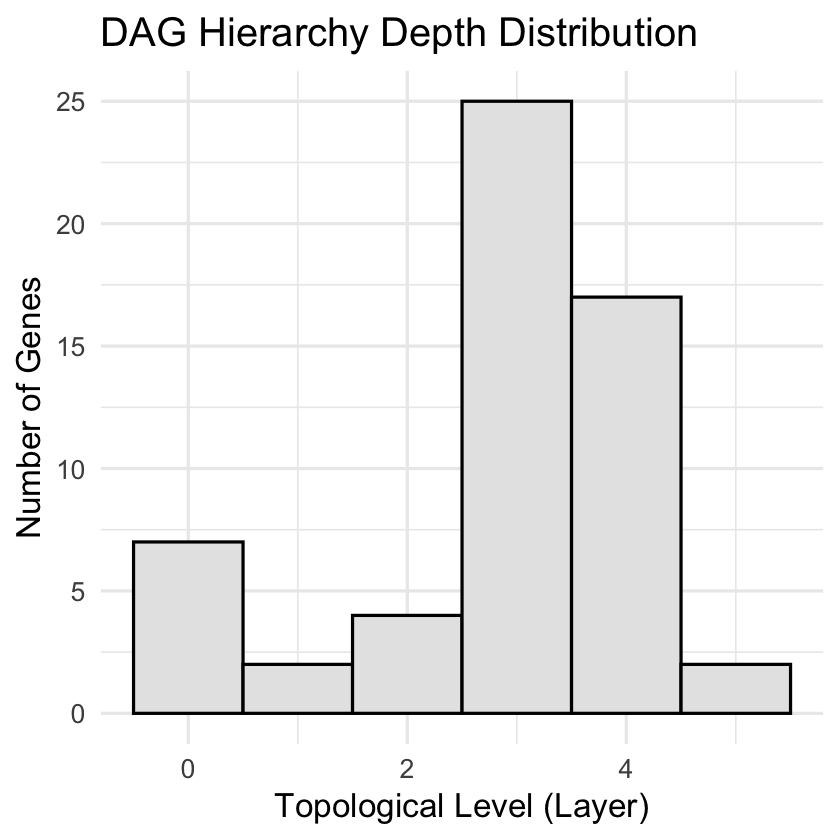

In [6]:
options(repr.plot.width = 7, repr.plot.height = 7)
g <- graph_from_data_frame(true_edges_name[,c("from_gene","to_gene")], directed=TRUE)

# Topological level (longest-path layering)
lvl <- suppressWarnings(distances(g, mode="in"))
level_vec <- apply(lvl, 2, function(x) if(all(is.infinite(x))) 0 else max(x[is.finite(x)]))

level_tbl <- tibble(
  gene = names(level_vec),
  level = level_vec
)

g_depth=ggplot(level_tbl, aes(x = level)) +
  geom_histogram(binwidth = 1, fill = "gray90", color = "black") +
  theme_minimal(base_size = 20) +
  xlab("Topological Level (Layer)") +
  ylab("Number of Genes") +
  ggtitle("DAG Hierarchy Depth Distribution")
g_depth

# Fig. 6c

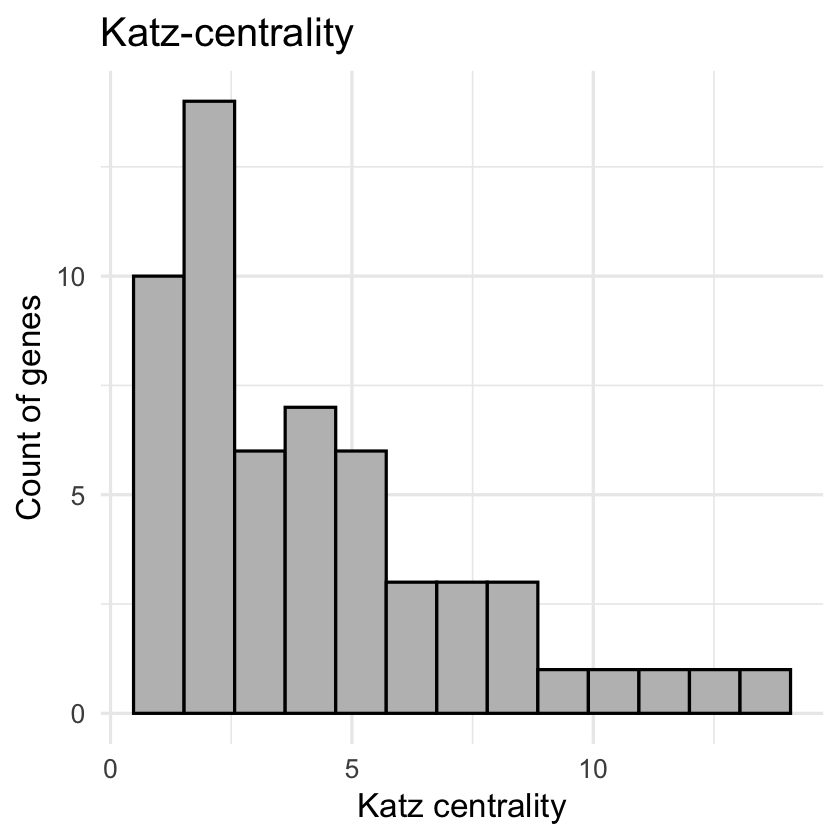

In [7]:
options(repr.plot.width = 7, repr.plot.height = 7)
g_katz=ggplot(deg_tbl, aes(katz)) +
  geom_histogram(fill = "gray", color = "black",bins=13) +
  theme_minimal(base_size = 20) +
  xlab("Katz centrality") +
  ylab("Count of genes") +
  ggtitle("Katz-centrality")#+xlim(0,20)
g_katz

# Characterize in- and out-hubs with GO.

In [8]:
options(repr.plot.width = 7, repr.plot.height = 7)

deg_diff <- deg_tbl %>%
  mutate(diff = indegree - outdegree)

top_in  <- deg_diff %>%
  arrange(desc(diff)) %>%
  slice_head(n = 10) %>%
  mutate(hub_color = "tomato")

top_out <- deg_diff %>%
  arrange(diff) %>%
  slice_head(n = 10) %>%
  mutate(hub_color = "steelblue")

top_hubs <- bind_rows(top_in, top_out)
hubs_tomato   <- top_hubs %>% filter(indegree > outdegree)   # indegree-heavy
hubs_steelblue <- top_hubs %>% filter(outdegree > indegree)   # outdegree-heavy

map_to_entrez <- function(genes) {
  bitr(genes, fromType="SYMBOL", toType="ENTREZID", OrgDb=org.Hs.eg.db)$ENTREZID
}

eg_tomato    <- map_to_entrez(hubs_tomato$gene)
eg_steelblue <- map_to_entrez(hubs_steelblue$gene)


go_tomato <- enrichGO(
  gene          = eg_tomato,
  OrgDb         = org.Hs.eg.db,
  universe=bg_entrez,
  keyType       = "ENTREZID",
  ont           = "BP",
  pvalueCutoff  = 1,
  qvalueCutoff  = 1,
  readable      = TRUE
)

go_steelblue <- enrichGO(
  gene          = eg_steelblue,
  OrgDb         = org.Hs.eg.db,
  universe=bg_entrez,    
  keyType       = "ENTREZID",
  ont           = "BP",
  pvalueCutoff  = 1,
  qvalueCutoff  = 1,
  readable      = TRUE
)


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



# Fig. 7a,b

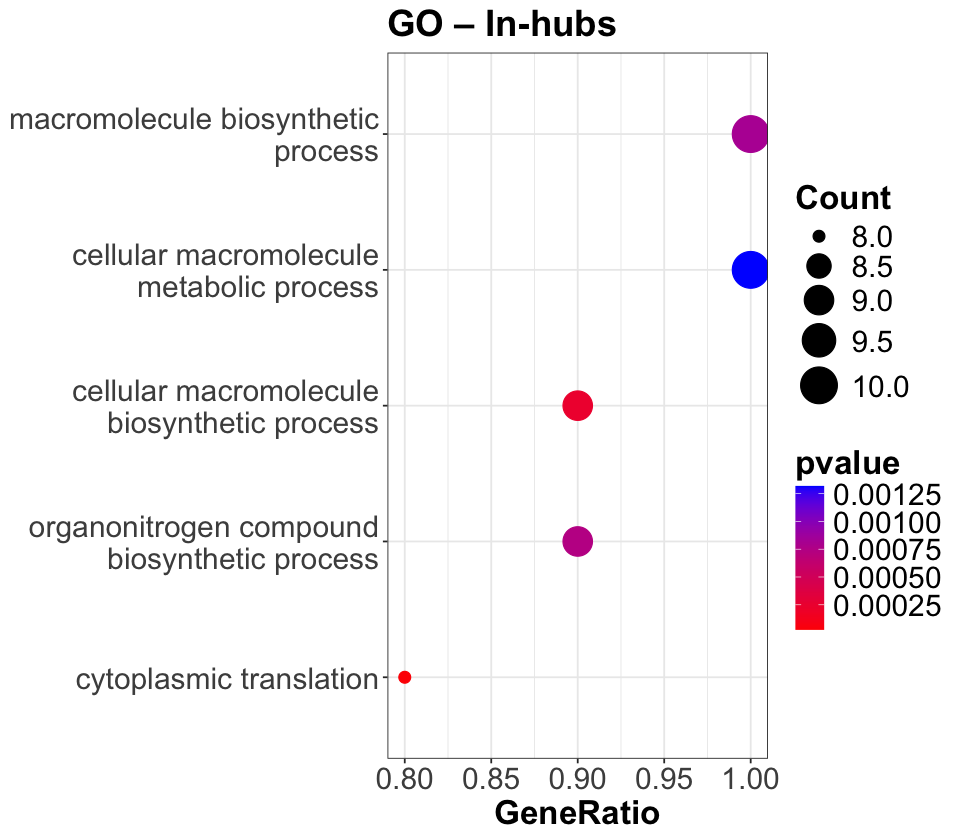

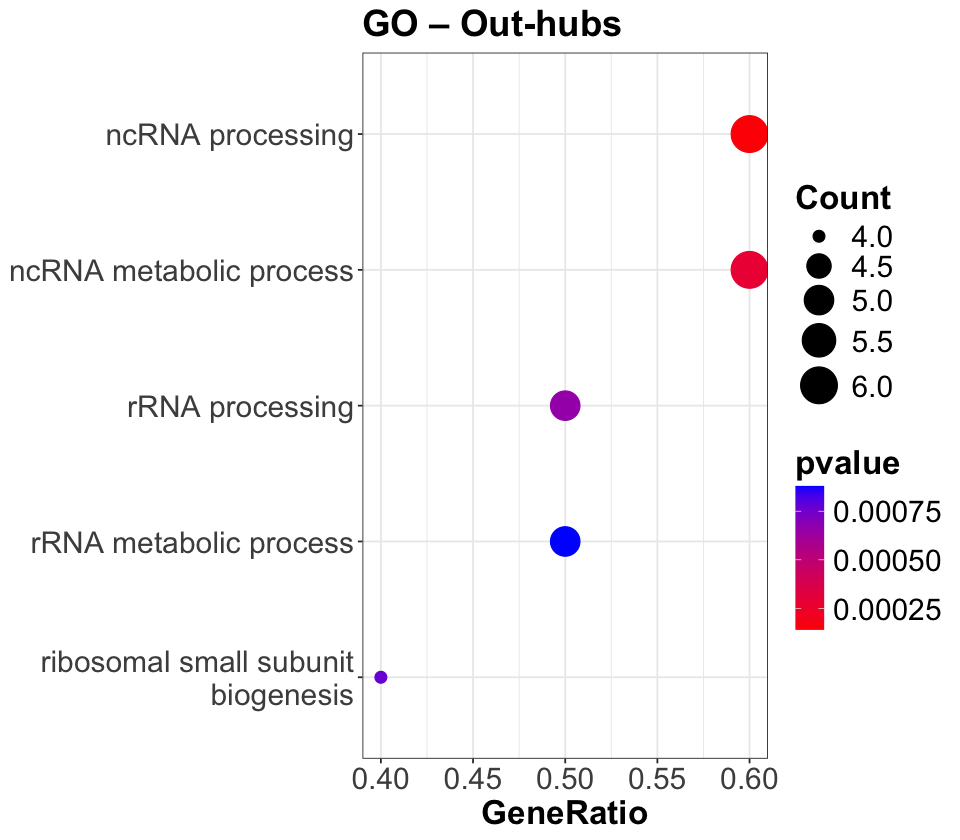

In [9]:
options(repr.plot.width = 8, repr.plot.height = 7)

# Convert enrichment results safely
df_tomato    <- as.data.frame(go_tomato)
df_steelblue <- as.data.frame(go_steelblue)

# A helper theme to enlarge everything
big_theme <- theme(
  plot.title      = element_text(size = 22, face = "bold"),
  axis.text       = element_text(size = 18),
  axis.title      = element_text(size = 20, face = "bold"),
  legend.text     = element_text(size = 18),
  legend.title    = element_text(size = 20, face = "bold"),
  strip.text      = element_text(size = 20)
)

prep_dotplot_df <- function(df, showCategory = 5, wrap_width = 30) {
  df <- df[order(df$pvalue), ]
  df <- head(df, showCategory)

  ratio_parts       <- strsplit(df$GeneRatio, "/")
  num               <- as.numeric(sapply(ratio_parts, `[`, 1))
  denom             <- as.numeric(sapply(ratio_parts, `[`, 2))
  df$GeneRatio_num  <- num / denom

   wrapped <- sapply(df$Description, function(x) paste(strwrap(x, width = wrap_width), collapse = "\n"))
  df$Description_wrapped <- wrapped

  
  ord <- order(df$GeneRatio_num, -df$pvalue)
  df$Description_wrapped <- factor(df$Description_wrapped,
                                    levels = unique(df$Description_wrapped[ord]))
  df
}

# Helper: build the plot manually (bypasses enrichplot's internal color scale)
make_dotplot <- function(df, title, wrap_width = 30) {
  d <- prep_dotplot_df(df, wrap_width = wrap_width)
  ggplot(d, aes(x = GeneRatio_num, y = Description_wrapped)) +
    geom_point(aes(size = Count, color = pvalue)) +
    scale_color_gradient(low = "red", high = "blue", name = "pvalue",
                          breaks = seq(0.00025, 0.00125, 0.00025)) +
    scale_size(range = c(3, 10), name = "Count") +
    guides(
      size  = guide_legend(order = 1),   # Count legend first (top)
      color = guide_colorbar(order = 2)  # pvalue legend second (below)
    ) +
    labs(title = title, x = "GeneRatio", y = NULL) +
    theme_bw() +
    big_theme
}

# Tomato panel (in-hubs)
p1 <- if (nrow(df_tomato) > 0) {
  make_dotplot(df_tomato, "GO – In-hubs")
} else {
  ggplot() + 
    ggtitle("Tomato: No Enriched GO Terms") +
    big_theme
}

# Steelblue panel (out-hubs)
p2 <- if (nrow(df_steelblue) > 0) {
  make_dotplot(df_steelblue, "GO – Out-hubs")
} else {
  ggplot() + 
    ggtitle("Steelblue: No Enriched GO Terms") +
    big_theme
}

p1
p2

# Read in GTF file containing gene location information

In [10]:
setwd(paste0(DIR,'/data/auxiliary'))
gtf=readRDS('gtf.rds')

# Fig. 7c

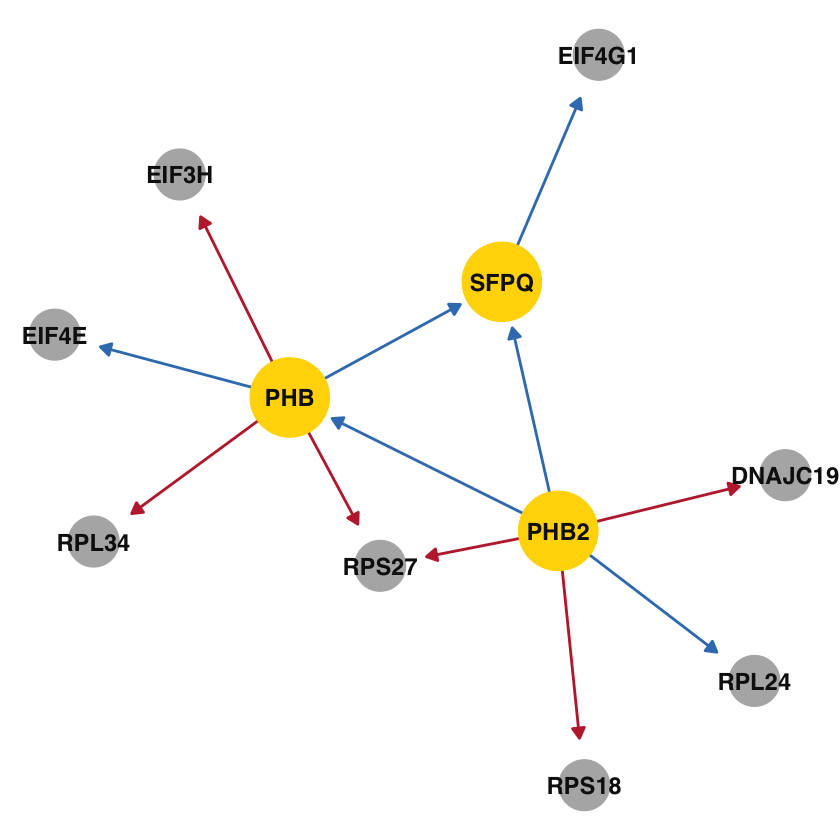

In [11]:
options(repr.plot.width = 7, repr.plot.height = 7)
# 1. Load the edge data
edges_raw <- true_edges_name %>% filter(from_gene%in%c("PHB","PHB2","SFPQ"))

# 2. Define Nodes and Edges separately
# Extract all unique genes to define which ones are TFs
nodes <- bind_rows(
  edges_raw %>% dplyr::select(name = from_gene),
  edges_raw %>% dplyr::select(name = to_gene)
) %>% 
  distinct() %>%
  # Flag the TFs so we can style them differently
  mutate(is_TF = name %in% c("PHB", "PHB2", "SFPQ"))

# Format the edges
edges <- edges_raw %>%
  dplyr::select(from = from_gene, to = to_gene, coef) %>%
  mutate(Effect = ifelse(coef > 0, "Positive", "Negative"))

# Create the graph object specifying both nodes and edges
net <- tbl_graph(nodes = nodes, edges = edges, directed = TRUE)

# 3. Plot the network
set.seed(1) 
g=ggraph(net, layout = 'fr') + 
  # Add curved edges
  geom_edge_arc(
    aes(edge_color = Effect),
    strength = 0, 
    width = 0.8,
    arrow = arrow(length = unit(2.5, 'mm'), type = "closed"),
    # Add caps so the lines don't bleed into the node circles
    start_cap = circle(5, 'mm'), 
    end_cap = circle(10, 'mm')
  ) +
  # Draw nodes, mapping size and color to whether it's a TF
  geom_node_point(
    aes(color = is_TF, size = is_TF)
  ) +
  # Place text dead-center inside the nodes
  geom_node_text(
    aes(label = name), 
    fontface = "bold", 
    color = "#111111", # Dark grey/black text
    size = 5
  ) +
  # Custom colors matching your screenshot
  scale_color_manual(values = c("TRUE" = "gold", "FALSE" = "gray70")) +
  scale_size_manual(values = c("TRUE" = 22, "FALSE" = 14)) +
  # Edge colors
  scale_edge_color_manual(
    values = c("Positive" = "#3A7EBD", "Negative" = "#BE2A3A")
  ) +
  theme_graph(base_family = "sans") +
  theme(legend.position = "none")

g+ 
  theme(plot.margin = margin(t = 0, r =0, b = 0, l = 0, unit = "pt")) +
  scale_x_continuous(expand = expansion(mult = 0.075)) +
  scale_y_continuous(expand = expansion(mult = 0.075))


# Visualize the RPS27 and SFPQ regions with Chip-seq information of PHB and PHB2 overlayed.

## Fig. 7d

  seqnames    start      end
1     chr1 35191646 35194645


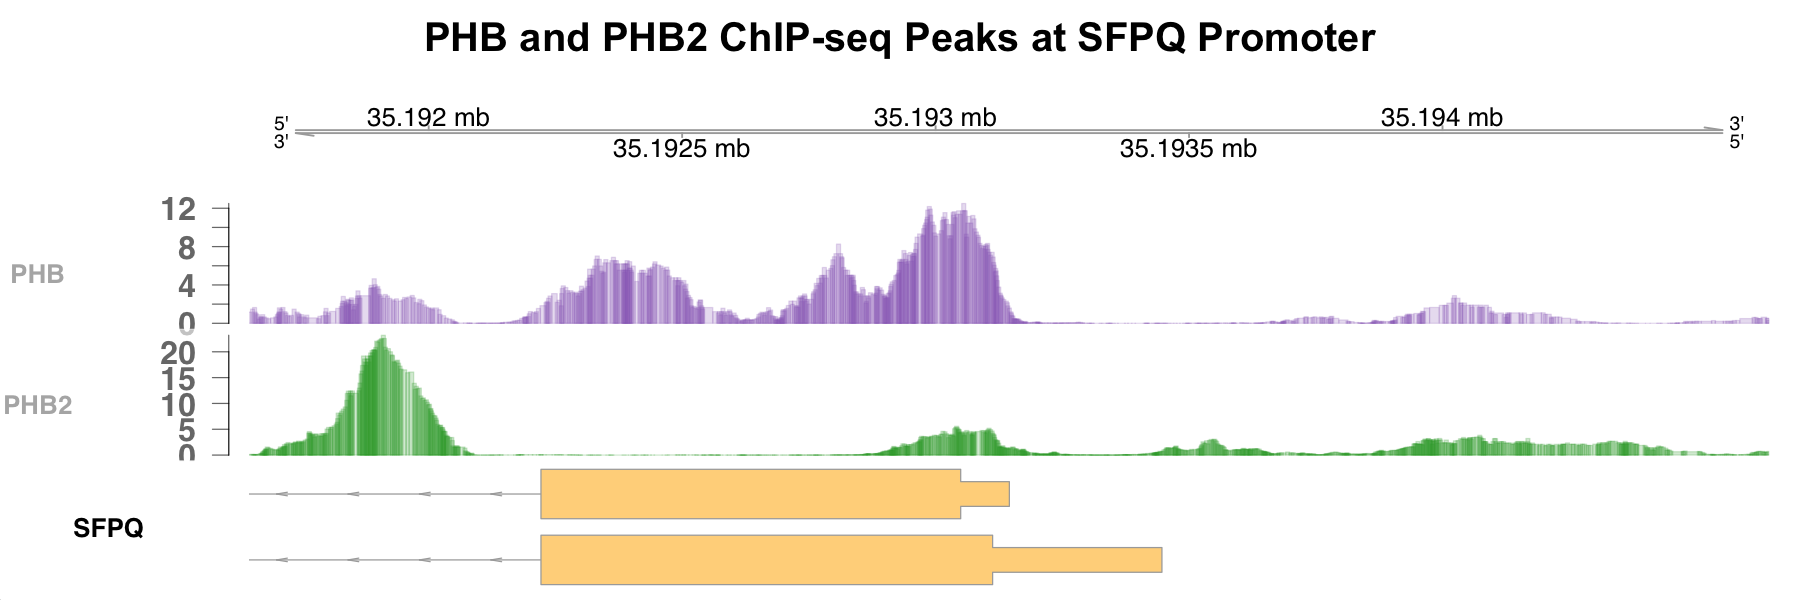

In [12]:
# 1. Filter for SFPQ transcripts
sfpq_transcripts <- gtf[gtf$gene_name == "SFPQ" & gtf$type == "gene", ]

# 2. Extract regions to plot
promoters_sfpq <- promoters(sfpq_transcripts, upstream = 1500, downstream = 1500)

# 3. Extract the coordinates into a dataframe
promoter_info <- as.data.frame(promoters_sfpq) %>%
  dplyr::select(seqnames, start, end) %>%
  distinct()

# View the results
print(promoter_info)

# 4. Use these variables for your Gviz plot
chr <- as.character(promoter_info$seqnames[1])
start_pos <- promoter_info$start[1]
end_pos <- promoter_info$end[1]

# 2. Set up the Axis and Gene Model Tracks
axis_track <- GenomeAxisTrack(
  cex = 1.2,
  fontsize = 13,
  lwd = 1.5,
  col = "darkgrey",
  fontcolor = "black",
  add53 = TRUE,
  add35 = TRUE
)

txdb <- TxDb.Hsapiens.UCSC.hg38.knownGene
gene_track <- GeneRegionTrack(txdb, chromosome = chr, start = start_pos, end = end_pos, 
                              name = "SFPQ", transcriptAnnotation = "gene_name",
                              fontsize = 13,
                              fontface.title = "bold",
                              col.title = "black",showId=FALSE)


options(repr.plot.width = 15, repr.plot.height = 5)

phb_track <- DataTrack(range = "PHB_subset.bigWig", 
                       genome = "hg38", 
                       type = "histogram",      
                       chromosome = chr, 
                       name = "PHB", 
                       col.histogram = "#9467BD", 
                       fill.histogram = "#9467BD",
                       alpha = 0.6,              
                       col.axis="black",
                              fontsize = 13,
                              fontface.title = "bold",cex.axis=1.5)      

phb2_track <- DataTrack(range = "PHB2_subset.bigWig", 
                        genome = "hg38", 
                        type = "histogram",     
                        chromosome = chr, 
                        name = "PHB2", 
                        col.histogram = "#2CA02C", 
                        fill.histogram = "#2CA02C",
                        alpha = 0.6,
                              fontsize = 13,
                              fontface.title = "bold",
                              col.title = "black",col.axis="black",cex.axis=1.5)        


plotTracks(list(axis_track, phb_track, phb2_track, gene_track), 
           from = start_pos, to = end_pos,
           sizes = c(2, 2, 2, 2), 
           main = "PHB and PHB2 ChIP-seq Peaks at SFPQ Promoter",
           background.title = "white",      
           fontcolor.title = "black",       
           rot.title = 0,                   
           just.title = "left",             
           cex.main = 2)

  seqnames     start       end
1     chr1 153989262 153992261


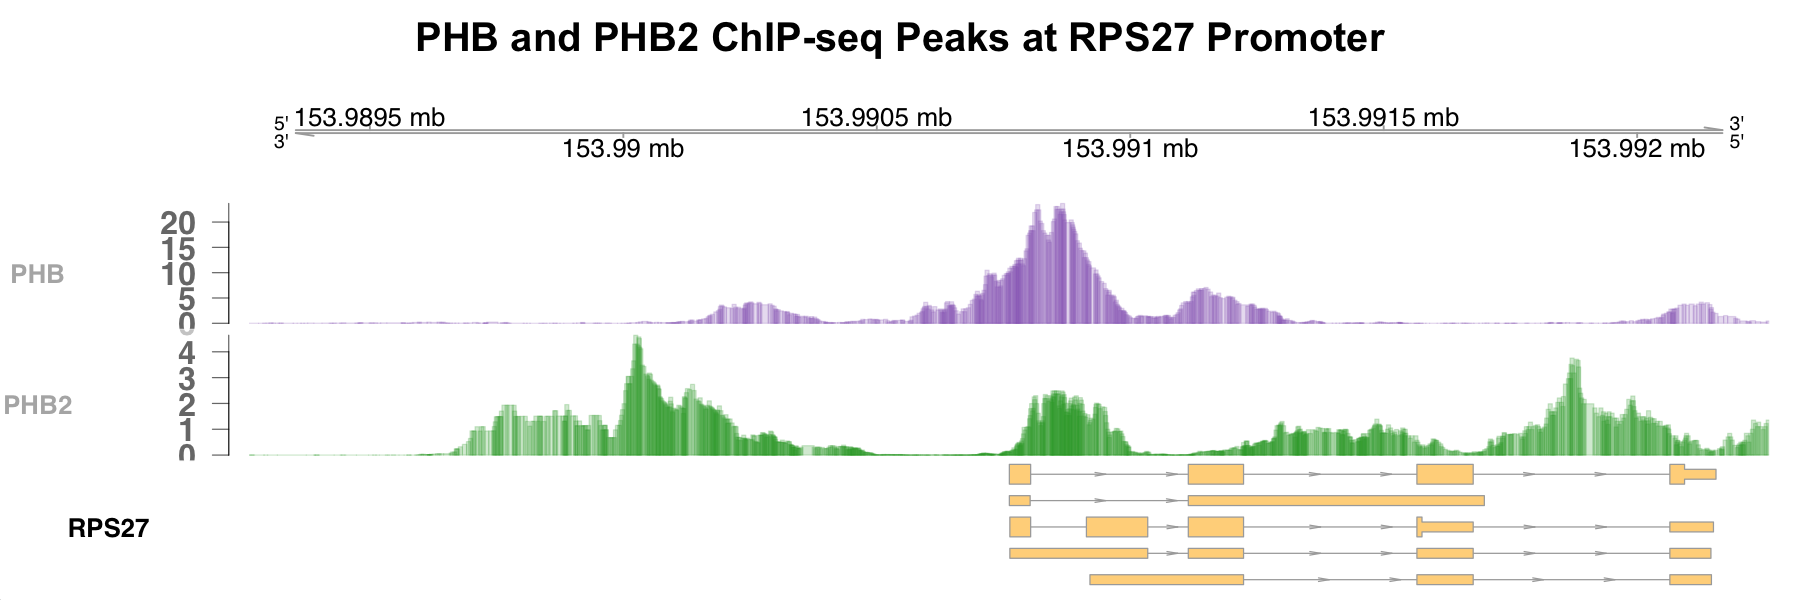

In [13]:
# 1. Filter for SFPQ transcripts
sfpq_transcripts <- gtf[gtf$gene_name == "RPS27" & gtf$type == "gene", ]

# 2. Extract regions to plot
promoters_sfpq <- promoters(sfpq_transcripts, upstream = 1500, downstream = 1500)

# 3. Extract the coordinates into a dataframe
promoter_info <- as.data.frame(promoters_sfpq) %>%
  dplyr::select(seqnames, start, end) %>%
  distinct()

# View the results
print(promoter_info)

# 4. Use these variables for your Gviz plot
chr <- as.character(promoter_info$seqnames[1])
start_pos <- promoter_info$start[1]
end_pos <- promoter_info$end[1]

# 2. Set up the Axis and Gene Model Tracks
axis_track <- GenomeAxisTrack(
  cex = 1.2,
  fontsize = 13,
  lwd = 1.5,
  col = "darkgrey",
  fontcolor = "black",
  add53 = TRUE,
  add35 = TRUE
)

txdb <- TxDb.Hsapiens.UCSC.hg38.knownGene
gene_track <- GeneRegionTrack(txdb, chromosome = chr, start = start_pos, end = end_pos, 
                              name = "RPS27", transcriptAnnotation = "gene_name",
                              fontsize = 13,
                              fontface.title = "bold",
                              col.title = "black",showId=FALSE)



options(repr.plot.width = 15, repr.plot.height = 5)


plotTracks(list(axis_track, phb_track, phb2_track, gene_track), 
           from = start_pos, to = end_pos,
           sizes = c(2, 2, 2, 2), 
           main = "PHB and PHB2 ChIP-seq Peaks at RPS27 Promoter",
           background.title = "white",      
           fontcolor.title = "black",       
           rot.title = 0,                   
           just.title = "left",             
           cex.main = 2)